# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   Dataset menggunakan Predict Students' Dropout and Academic Success (https://archive.ics.uci.edu/dataset/697/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", 100)

Matplotlib is building the font cache; this may take a moment.


In [2]:
import sklearn
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

pandas: 2.3.3
numpy: 2.4.2
sklearn: 1.8.0


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [9]:
DATA_PATH = os.path.join("..", "namadataset_raw", "data.csv")
df = pd.read_csv(DATA_PATH)

df = pd.read_csv(DATA_PATH, sep=";")

print("Shape:", df.shape)
df.head()

Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [10]:
df.info()
df.describe(include="all").T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance\t,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [11]:
(df.isna().sum().sort_values(ascending=False).head(15))

Marital status                                    0
Age at enrollment                                 0
Curricular units 1st sem (credited)               0
Curricular units 1st sem (enrolled)               0
Curricular units 1st sem (evaluations)            0
Curricular units 1st sem (approved)               0
Curricular units 1st sem (grade)                  0
Curricular units 1st sem (without evaluations)    0
Curricular units 2nd sem (credited)               0
Curricular units 2nd sem (enrolled)               0
Curricular units 2nd sem (evaluations)            0
Curricular units 2nd sem (approved)               0
Curricular units 2nd sem (grade)                  0
Curricular units 2nd sem (without evaluations)    0
Unemployment rate                                 0
dtype: int64

In [12]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


In [21]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r"\s+", " ", regex=True)
df.columns
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [22]:
[c for c in df.columns if "\t" in c]

[]

In [23]:
df["Target"].value_counts(normalize=True)
df.corr(numeric_only=True)["Age at enrollment"].sort_values(ascending=False).head(10)

Age at enrollment                      1.000000
Marital status                         0.522717
Application mode                       0.516243
Mother's qualification                 0.294614
Curricular units 1st sem (credited)    0.226837
Curricular units 2nd sem (credited)    0.207561
Father's qualification                 0.193505
Previous qualification                 0.156234
Gender                                 0.148835
Curricular units 1st sem (enrolled)    0.141327
Name: Age at enrollment, dtype: float64

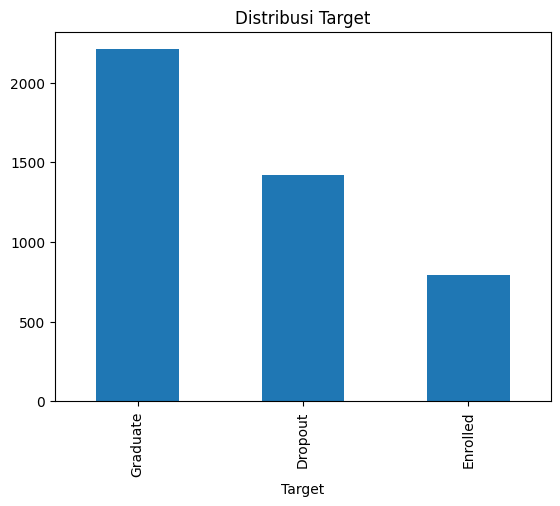

In [24]:
df["Target"].value_counts().plot(kind="bar")
plt.title("Distribusi Target")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [25]:
target_col = "Target"
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

In [32]:
mapping = {k: int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}
with open(os.path.join(OUT_DIR, "label_mapping.json"), "w") as f:
    json.dump(mapping, f, indent=2)
print("Label mapping:", mapping)

Label mapping: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (3539, 36)
X_test_scaled : (885, 36)


In [35]:
OUT_DIR = "namadataset_preprocessing"
os.makedirs(OUT_DIR, exist_ok=True)

np.save(os.path.join(OUT_DIR, "X_train.npy"), X_train_scaled)
np.save(os.path.join(OUT_DIR, "X_test.npy"), X_test_scaled)
np.save(os.path.join(OUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUT_DIR, "y_test.npy"), y_test)

# simpan juga nama kolom (penting untuk interpretasi)
np.save(os.path.join(OUT_DIR, "feature_names.npy"), np.array(X.columns))

In [36]:
import json
with open(os.path.join(OUT_DIR, "label_mapping.json"), "w") as f:
    json.dump({k: int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}, f, indent=2)

print("Saved to:", os.path.abspath(OUT_DIR))


Saved to: /Users/ahmadngiliyun/Downloads/Documents/Eksperimen_SML_Ahmad-Ngiliyun/preprocessing/namadataset_preprocessing


In [37]:
import numpy as np
import os

OUT_DIR = "namadataset_preprocessing"
Xtr = np.load(os.path.join(OUT_DIR, "X_train.npy"))
ytr = np.load(os.path.join(OUT_DIR, "y_train.npy"))

print("Loaded:", Xtr.shape, ytr.shape)
print("Sample y:", ytr[:10])

Loaded: (3539, 36) (3539,)
Sample y: [2 0 1 2 2 1 0 0 0 0]
